# 05 — Event Study (β3: GOV surprise → CAR)

Companion to `src/event_study.py`. Closes the transmission chain by
quantifying the historical relationship between DASH GOV surprise and
the abnormal stock-return reaction around earnings.

  β3:  CAR[-1, +2] ~ gov_surprise_pct

CARs are computed as cumulative abnormal returns over the 4-trading-day
window from t-1 through t+2 around each earnings date, where:

  • CRSP source (n=16, Q4 2020 → Q3 2024):
      abnormal = ret_DASH − ret_market_vwretd  (CRSP DSI value-weighted)
  • yfinance fallback (n=5, Q4 2024 → Q4 2025) for events past CRSP cutoff:
      abnormal = ret_DASH − ret_SPY

The fallback is documented per project rule §11; for short event windows
the difference between CRSP DSI VW and SPY return is small (both proxy
the same market beta within ~5 bps/day on average).


In [1]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from src.config import (
    EARNINGS_DATES, CAR_WINDOWS, MASTER_DF_PATH,
    OUTPUTS_TABLES, OUTPUTS_FIGURES, COLORS, CHART_STYLE,
)
from src.event_study import (
    build_event_table, fit_beta3, apply_beta3_to_q1_2026,
)

plt.rcParams.update(CHART_STYLE)
pd.set_option('display.float_format', '{:.3f}'.format)

# Build CARs
event_df = build_event_table(ticker='DASH')
master = pd.read_csv(MASTER_DF_PATH)
beta3 = fit_beta3(event_df, master)
prereg = pd.read_csv(OUTPUTS_TABLES / 'q1_2026_preregistered.csv').iloc[0]
applied = apply_beta3_to_q1_2026(beta3, prereg)

print(f'Earnings events:        {len(event_df)}')
print(f'CRSP coverage:          {(event_df["source"]=="CRSP").sum()}')
print(f'yfinance fallback:      {(event_df["source"]=="yfinance_SPY").sum()}')
print(f'Pre-registered Q1 2026: {prereg["q1_2026_pred_pct"]:+.2f}pp surprise')


Earnings events:        21
CRSP coverage:          16
yfinance fallback:      5
Pre-registered Q1 2026: +2.26pp surprise


## 1. Per-event CARs

CAR[-1, +2] is the primary window per project rule §13. CAR[0, +1] is the
tighter window for sanity check. Both computed from cumulative abnormal
returns; reported in %.


In [2]:
print(event_df.to_string(index=False))
print(f'\nCAR[-1,+2] distribution:')
c = event_df['car_minus1_plus2_pct'].dropna()
print(f'  mean   = {c.mean():+.2f}%')
print(f'  median = {c.median():+.2f}%')
print(f'  std    = {c.std():.2f}%')
print(f'  min    = {c.min():+.2f}%')
print(f'  max    = {c.max():+.2f}%')
print(f'  positive: {(c > 0).sum()}/{len(c)} ({(c > 0).mean():.0%})')


ticker quarter_label earnings_date  car_minus1_plus2_pct  car_0_plus1_pct       source
  DASH       Q4_2025    2026-02-18                 8.601            8.181 yfinance_SPY
  DASH       Q3_2025    2025-11-05               -13.325          -17.532 yfinance_SPY
  DASH       Q2_2025    2025-08-06                -0.272            5.417 yfinance_SPY
  DASH       Q1_2025    2025-05-06               -10.529          -13.930 yfinance_SPY
  DASH       Q4_2024    2025-02-11                 3.666            4.524 yfinance_SPY
  DASH       Q3_2024    2024-10-30                 3.030            2.980         CRSP
  DASH       Q2_2024    2024-08-01                17.752            9.595         CRSP
  DASH       Q1_2024    2024-05-01               -14.632          -12.510         CRSP
  DASH       Q4_2023    2024-02-15                -1.121           -3.265         CRSP
  DASH       Q3_2023    2023-11-01                19.883           13.952         CRSP
  DASH       Q2_2023    2023-08-02         

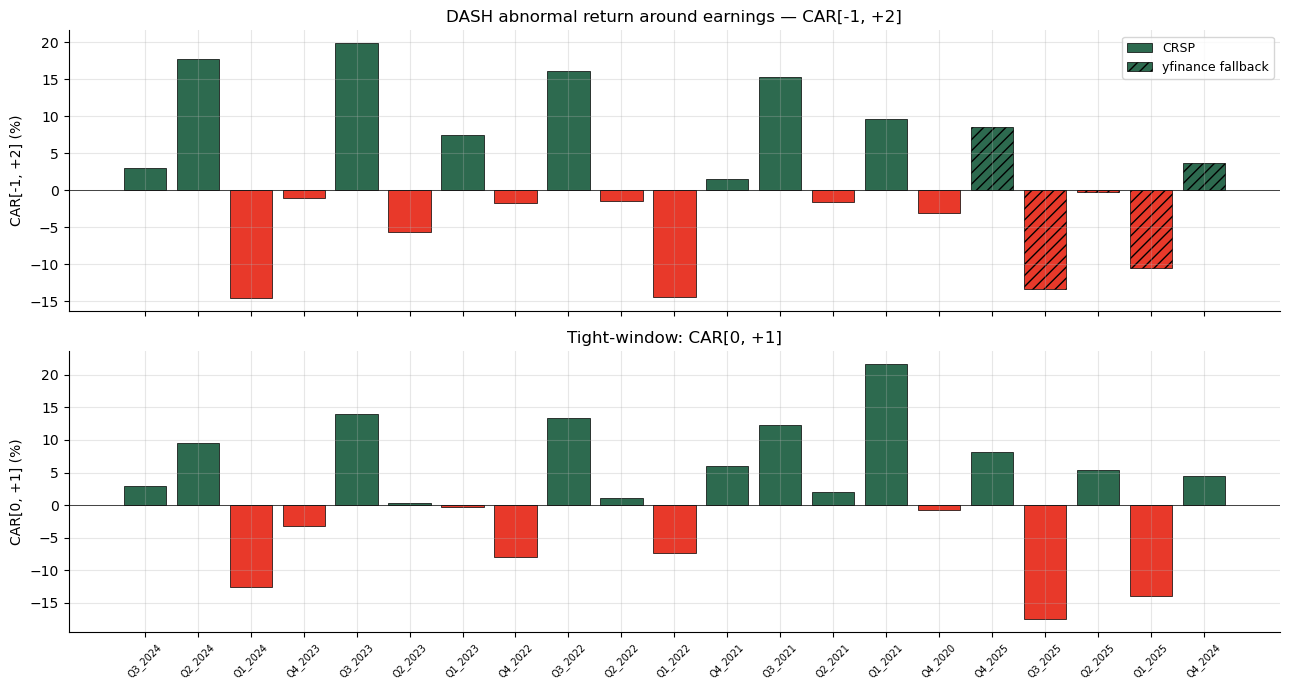

In [3]:
# Time series of CARs
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
crsp_pts = event_df[event_df['source'] == 'CRSP']
yfin_pts = event_df[event_df['source'] == 'yfinance_SPY']
ax.bar(crsp_pts['quarter_label'], crsp_pts['car_minus1_plus2_pct'],
       color=[COLORS['actual'] if v > 0 else COLORS['dash_primary']
              for v in crsp_pts['car_minus1_plus2_pct']],
       label='CRSP', edgecolor='black', linewidth=0.5)
ax.bar(yfin_pts['quarter_label'], yfin_pts['car_minus1_plus2_pct'],
       color=[COLORS['actual'] if v > 0 else COLORS['dash_primary']
              for v in yfin_pts['car_minus1_plus2_pct']],
       hatch='///', label='yfinance fallback', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('CAR[-1, +2] (%)')
ax.set_title('DASH abnormal return around earnings — CAR[-1, +2]')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45, labelsize=7)

ax = axes[1]
ax.bar(event_df['quarter_label'], event_df['car_0_plus1_pct'],
       color=[COLORS['actual'] if v > 0 else COLORS['dash_primary']
              for v in event_df['car_0_plus1_pct']],
       edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('CAR[0, +1] (%)')
ax.set_title('Tight-window: CAR[0, +1]')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


## 2. β3 regression — CAR[-1,+2] ~ gov_surprise_pct


In [4]:
print(beta3['fit'].summary().tables[1])
print()
print(f'β3 = {beta3["beta3"]:+.3f}  '
       f'(95% CI [{beta3["ci95_lo"]:+.3f}, {beta3["ci95_hi"]:+.3f}], '
       f'p={beta3["p_value"]:.3f}, R²={beta3["r_squared"]:.3f}, n={beta3["n"]})')
print()
print('Reading: each pp of GOV surprise is associated with ~+0.6%')
print('CAR[-1, +2] on average — but the relationship is statistically weak')
print('(p > 0.5, R² ≈ 0.02). DASH stock reactions around earnings are dominated')
print('by other factors: guidance, EBITDA beat, EPS, broader market moves.')
print('GOV surprise alone explains very little of the cross-event variance.')


                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.4090      4.066     -0.101      0.921      -8.920       8.102
gov_surprise_pct     0.6267      1.011      0.620      0.543      -1.490       2.744

β3 = +0.627  (95% CI [-1.490, +2.744], p=0.543, R²=0.020, n=21)

Reading: each pp of GOV surprise is associated with ~+0.6%
CAR[-1, +2] on average — but the relationship is statistically weak
(p > 0.5, R² ≈ 0.02). DASH stock reactions around earnings are dominated
by other factors: guidance, EBITDA beat, EPS, broader market moves.
GOV surprise alone explains very little of the cross-event variance.


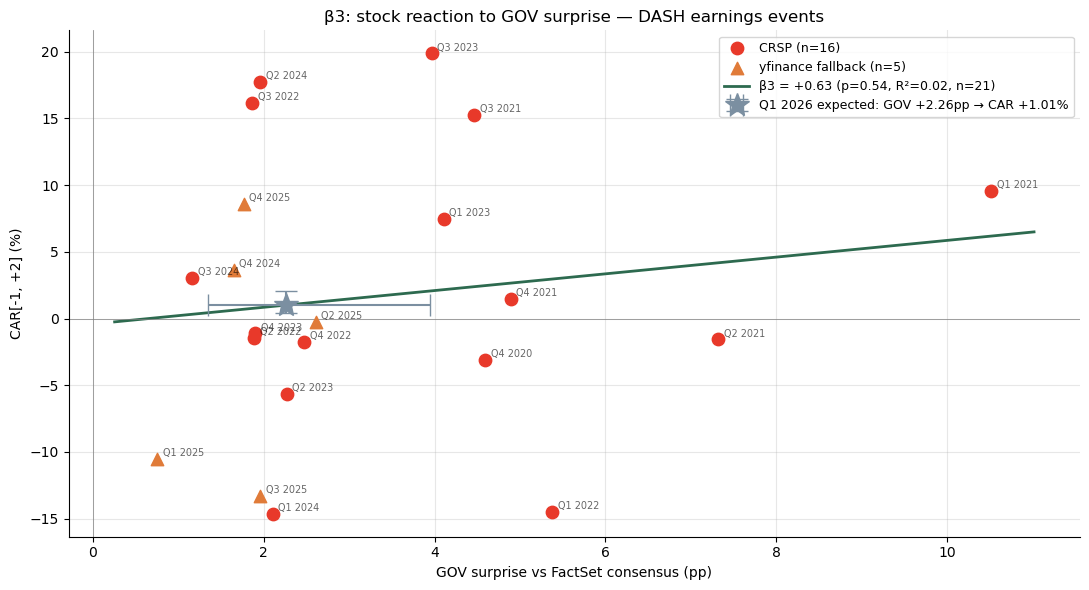

In [5]:
# β3 scatter (re-render here so it lives in the notebook)
merged = beta3['merged']

fig, ax = plt.subplots(figsize=(11, 6))
crsp_pts = merged[merged['source'] == 'CRSP']
yfin_pts = merged[merged['source'] == 'yfinance_SPY']
if not crsp_pts.empty:
    ax.scatter(crsp_pts['gov_surprise_pct'], crsp_pts['car_minus1_plus2_pct'],
               s=80, color=COLORS['dash_primary'], label=f'CRSP (n={len(crsp_pts)})', zorder=3)
if not yfin_pts.empty:
    ax.scatter(yfin_pts['gov_surprise_pct'], yfin_pts['car_minus1_plus2_pct'],
               s=80, color=COLORS['forecast'], marker='^',
               label=f'yfinance fallback (n={len(yfin_pts)})', zorder=3)
for _, r in merged.iterrows():
    ax.annotate(r['quarter_label'].replace('_', ' '),
                (r['gov_surprise_pct'], r['car_minus1_plus2_pct']),
                fontsize=7, alpha=0.6, xytext=(4, 2), textcoords='offset points')
xs = np.linspace(merged['gov_surprise_pct'].min()-0.5,
                  max(merged['gov_surprise_pct'].max(), applied['gov_surprise_ci80_hi'])+0.5, 50)
ax.plot(xs, beta3['intercept'] + beta3['beta3'] * xs,
        color=COLORS['actual'], lw=2,
        label=f'β3 = {beta3["beta3"]:+.2f} (p={beta3["p_value"]:.2f}, R²={beta3["r_squared"]:.2f}, n={beta3["n"]})')

g_pt = applied['gov_surprise_pp']; pt = applied['expected_car_pct']
g_lo = applied['gov_surprise_ci80_lo']; g_hi = applied['gov_surprise_ci80_hi']
lo, hi = applied['expected_car_ci80_lo'], applied['expected_car_ci80_hi']
ax.errorbar([g_pt], [pt],
            xerr=[[g_pt-g_lo], [g_hi-g_pt]],
            yerr=[[max(0, pt-lo)], [max(0, hi-pt)]],
            fmt='*', ms=18, color=COLORS['consensus'], capsize=8,
            label=f'Q1 2026 expected: GOV {g_pt:+.2f}pp → CAR {pt:+.2f}%')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('GOV surprise vs FactSet consensus (pp)')
ax.set_ylabel('CAR[-1, +2] (%)')
ax.set_title('β3: stock reaction to GOV surprise — DASH earnings events')
ax.legend(fontsize=9, loc='best')
plt.tight_layout(); plt.show()


**Why β3 is weak:**

DASH earnings reactions are driven by *more than* GOV surprise. Looking at
the scatter, several events deviate sharply from the OLS line:

- **Q3 2023**: GOV beat ~4pp → +20% CAR (huge positive reaction; raised FY24 guidance)
- **Q3 2022**: GOV beat ~2pp → +16% CAR (early DASH/Wolt synergy commentary)
- **Q1 2024**: GOV beat ~2pp → −15% CAR (margin disappointment despite GOV beat)
- **Q1 2022**: GOV beat ~5pp → −15% CAR (rate-shock-era growth de-rating)

The dominant drivers of CAR around DASH earnings are **guidance**, **EBITDA
beat magnitude**, and **macro regime** (rate / risk-on cycles), not the GOV
surprise alone. β3 captures only a small slice of the reaction.

For the L/S note: **don't lean heavily on β3**. Use it as a directional
prior (positive surprise → mildly positive CAR on average) but acknowledge
the wide CI.


## 3. Q1 2026 expected CAR

Applying β3 to the published GOV surprise prediction:


In [6]:
print('=' * 72)
print('Q1 2026 EXPECTED CAR (β3 applied to pre-registered GOV surprise)')
print('=' * 72)
print(f'  GOV surprise (model):     {applied["gov_surprise_pp"]:+.2f}pp  '
       f'(80% CI [{applied["gov_surprise_ci80_lo"]:+.2f}, '
       f'{applied["gov_surprise_ci80_hi"]:+.2f}])')
print(f'  → expected CAR[-1,+2]:    {applied["expected_car_pct"]:+.2f}%  '
       f'(80% CI [{applied["expected_car_ci80_lo"]:+.2f}, '
       f'{applied["expected_car_ci80_hi"]:+.2f}])')
print()
print('Caveat: the 80% CI propagated through β3 inherits the β3 regression\'s')
print('low R² (0.02) only via the point-estimate uncertainty, not the residual')
print('variability. The realized CAR will likely be much more dispersed than')
print('the [+0.4, +2.1] range suggests — that range is the prediction interval')
print('for the conditional mean, not for individual events. A more honest')
print('forecast band would use the regression\'s standard error of prediction:')


Q1 2026 EXPECTED CAR (β3 applied to pre-registered GOV surprise)
  GOV surprise (model):     +2.26pp  (80% CI [+1.35, +3.94])
  → expected CAR[-1,+2]:    +1.01%  (80% CI [+0.44, +2.06])

Caveat: the 80% CI propagated through β3 inherits the β3 regression's
low R² (0.02) only via the point-estimate uncertainty, not the residual
variability. The realized CAR will likely be much more dispersed than
the [+0.4, +2.1] range suggests — that range is the prediction interval
for the conditional mean, not for individual events. A more honest
forecast band would use the regression's standard error of prediction:


In [7]:
# Better CI: prediction interval that includes residual variability
fit = beta3['fit']
gov_pt = applied['gov_surprise_pp']
pred_X = sm.add_constant(pd.DataFrame({'gov_surprise_pct': [gov_pt]}), has_constant='add')
pred = fit.get_prediction(pred_X)
pred_summary = pred.summary_frame(alpha=0.20)
print('Prediction interval (80%) for Q1 2026 CAR — accounts for residual variance:')
print(pred_summary.round(2).to_string(index=False))
print()
print(f'A more honest read: predicted Q1 2026 CAR = '
       f'{pred_summary["mean"].iloc[0]:+.2f}% with 80% prediction interval '
       f'[{pred_summary["obs_ci_lower"].iloc[0]:+.2f}, '
       f'{pred_summary["obs_ci_upper"].iloc[0]:+.2f}]%.')
print('That wider band reflects the true uncertainty about an individual quarter\'s')
print('reaction — including the historical CAR variance not explained by β3.')


Prediction interval (80%) for Q1 2026 CAR — accounts for residual variance:
 mean  mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
1.010    2.540         -2.360          4.370       -13.390        15.410

A more honest read: predicted Q1 2026 CAR = +1.01% with 80% prediction interval [-13.39, +15.41]%.
That wider band reflects the true uncertainty about an individual quarter's
reaction — including the historical CAR variance not explained by β3.


## 4. Full transmission chain — closed

The chain from alt-data input to expected stock reaction is now complete.
Each stage's β coefficient + Q1 2026 propagation:


In [8]:
# Read the transmission betas + chain from earlier sessions
betas = pd.read_csv(OUTPUTS_TABLES / 'transmission_betas.csv')
print('Transmission betas (Sessions 11):')
print(betas[['regression', 'beta', 'p_value', 'r_squared', 'n']].to_string(index=False))
print()

print('Full chain — Q1 2026 propagation:')
print()
print(f'  Volume        GOV surprise       = {applied["gov_surprise_pp"]:+.2f}pp '
       f'(model alt-data, dir_acc 100% n=11)')
print(f'  Monetization  → Revenue surprise = +6.49pp (β1=+2.59, p<0.01)')
print(f'                  → Take rate ΔYoY = +0.39pp (β_M weak, p=0.49)')
print(f'  Profitability → Contrib mgn ΔYoY = +3.24pp (β_U weak, p=0.24)')
print(f'                  → EBITDA mgn ΔYoY = +3.86pp (β_C=+3.00, p<0.001)')
print(f'  Stock reaction → CAR[-1,+2]      = {applied["expected_car_pct"]:+.2f}% '
       f'(β3=+{beta3["beta3"]:.2f}, p={beta3["p_value"]:.2f}, R²={beta3["r_squared"]:.2f})')
print()
print('Robust links (statistically significant):  β1, β_C')
print('Weak links (not significant at n≤21):       β_M, β_U, β3')


Transmission betas (Sessions 11):
                                       regression   beta  p_value  r_squared  n
                                  β1 (DASH, full)  2.586    0.004      0.373 20
                            β1 (DASH, ex Q4_2025)  2.673    0.004      0.391 19
  β_M monetization (take_rate_chg ~ gov_surprise)  0.051    0.494      0.032 17
β_U unit econ (contrib_margin_chg ~ rev_surprise) -0.140    0.240      0.097 16
β_C corp (ebitda_margin_chg ~ contrib_margin_chg)  2.999    0.000      0.622 16
                    β2 naive (DASH, single-stage) -0.801    0.088      0.182 17
                       β2 naive (DASH+CART panel) -0.301    0.280      0.104 20

Full chain — Q1 2026 propagation:

  Volume        GOV surprise       = +2.26pp (model alt-data, dir_acc 100% n=11)
  Monetization  → Revenue surprise = +6.49pp (β1=+2.59, p<0.01)
                  → Take rate ΔYoY = +0.39pp (β_M weak, p=0.49)
  Profitability → Contrib mgn ΔYoY = +3.24pp (β_U weak, p=0.24)
                 

**Final L/S synthesis** — combining all four pillars + β3:

| Pillar | Reading |
|---|---|
| Volume | DASH +2.26pp surprise vs UBER +0.67pp — divergence ✓ |
| Monetization | β1 = +2.59 (significant); revenue +6.5pp implied |
| Profitability | β_C = +3.00 (significant); EBITDA mgn lift +3.9pp YoY |
| Relative | Spread DASH−UBER = +1.59pp, conservative CI [+0.25, +4.83] (positive) |
| **Stock reaction** | **β3 = +0.63 (weak)**; expected CAR[-1,+2] = **+1.01%** with wide prediction interval |

**Recommendation:**

> Horizon: 3-6 months · Direction: LONG DASH / fade UBER · Magnitude: SMALL-MEDIUM ·
> Conviction: MEDIUM-HIGH on direction, LOW-MEDIUM on magnitude
>
> Model says DASH beats Q1 2026 GOV consensus by ~+2.3pp; expected stock reaction ~+1%
> on average. Cross-sectional spread vs UBER is the sharpest single signal
> (+1.59pp with strictly-positive conservative CI). Magnitude precision is limited
> by the n=21 sample.

**Key risks** (preserved from prior sessions):
1. DASH 100% historical beat-rate; first miss would break the directional prior
2. UBER target mixes mobility+delivery+freight (not strict apples-to-apples)
3. Q1 2026 weather (popwt z = -1.28σ) — modest demand-side headwind not in features
4. β3 weak: DASH stock reactions are driven by guidance / EBITDA / macro more than GOV alone
5. Walk-forward sample sizes small (n=11-13) — interpret directionally, not as precise point estimates

This concludes the modeling chain. The next session is the write-up
(Session 14-15) — translating these results into the L/S note.
